In [ ]:
from iqptn.models import IQPTensorNetwork, local_gates
import time
import jax.numpy as jnp
import jax.random

n_qubits = 9
key = jax.random.PRNGKey(int(time.time_ns() & 0xFFFFFFFF))
interactions = local_gates(N = n_qubits, max_weight=3)
parameters = jax.random.uniform(key, shape=(len(interactions),), minval=0, maxval=2*jnp.pi)

iqp = IQPTensorNetwork(
    nqubits=n_qubits,
    interactions=interactions
)
circuit = iqp.build_circuit(parameters)

Let's generate a batch of boltzman distributions with increasing entropy

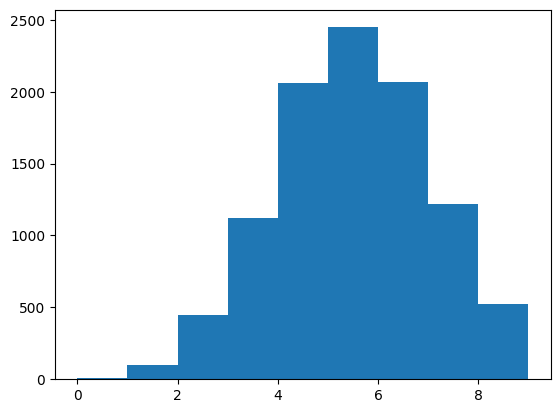

In [16]:
from iqptn.distributions.boltzman_entropy_generator import generate_distribution_with_target_entropy, sample_dataset_from_distribution
import matplotlib.pyplot as plt

n_states = 2**n_qubits
n_samples = 10000
target_entropy = jnp.log(n_samples) * 0.9
key = jax.random.PRNGKey(42)

key_dist, key_sample = jax.random.split(key)

ground_truth_dist = generate_distribution_with_target_entropy(n_states, target_entropy, key_dist)
training_data = sample_dataset_from_distribution(ground_truth_dist, n_qubits, n_samples, key_sample)

x = plt.hist(jnp.sum(training_data, axis = 1), bins = jnp.arange(0,n_qubits,1))


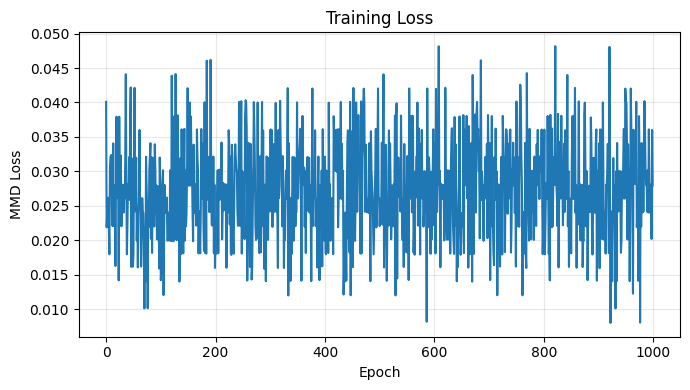

Training settings:
n_qubits      : 10
n_ops         : 512
lr            : 0.01
n_samples     : 1000
epochs        : 1000
sigma         : 0.989347
n_interactions: 129
n_parameters  : 129


In [24]:
import numpy as np
import jax.random as random
import jax.numpy as jnp
import matplotlib.pyplot as plt
from iqptn.euristics import sigma_heuristic
from iqptn.utils import convert_to_jnp_ndarray
from iqptn.optimizer import setup_training
from tqdm import tqdm

# Setup
n_ops = int(2**n_qubits * 0.5) # with 2^n_qubit we cover the space completly, but also we get noise and stuff
lr = 0.01
n_samples = 1000
epochs = 1000

generators = convert_to_jnp_ndarray(interactions, n_qubits=n_qubits)
sigma = sigma_heuristic(X=training_data)[0]

opt_state, train_step = setup_training(
    init_params=parameters, 
    generators=generators, 
    ground_truth=training_data, 
    sigma=sigma, 
    n_ops=n_ops, 
    n_samples=n_samples, 
    lr=lr,
)

loss_history = []
for _ in tqdm(range(epochs), desc="Training", leave=False):
    key, subkey = random.split(key)
    parameters, opt_state, loss_val = train_step(parameters, opt_state, subkey)
    loss_history.append(loss_val)

loss_history_np = np.asarray(jnp.stack(loss_history))
params_np = np.asarray(parameters)
np.savez(
    "training_results.npz",
    loss_history=loss_history_np,
    params=params_np,
    epochs=epochs,
    nqubits=n_qubits,
    sigma=float(sigma),
)

plt.figure(figsize=(7, 4))
plt.plot(loss_history_np)
plt.xlabel("Epoch")
plt.ylabel("MMD Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Training settings:")
print(f"n_qubits      : {n_qubits}")
print(f"n_ops         : {n_ops}")
print(f"lr            : {lr}")
print(f"n_samples     : {n_samples}")
print(f"epochs        : {epochs}")
print(f"sigma         : {float(sigma):.6f}")
print(f"n_interactions: {len(interactions)}")
print(f"n_parameters  : {parameters.shape[0]}")